# 📈 ETF Analysis using yfinance & Google Cloud
This notebook explores historical price data of selected ETFs using yfinance and complements it with Google BigQuery data sources.

## Start Setup

In [ ]:
# installl the library if it is not pre-intalled:
!pip install yfinance --upgrade

In [ ]:
# Common imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Asthetics

sns.set_theme(style="darkgrid", palette="muted")

## Get Data from `yFinance`

`yFinance` is a Python library that allows easy access to financial data directly from [Yahoo! Finance](https://finance.yahoo.com). It enables users to download historical prices, fundamental metrics, dividend information, and more — all through simple Python functions.

`yFinance` is used in this notebook in order to:

- To download **daily price data** for ETFs without manual CSV downloads.
- To automate access to **adjusted close prices**, essential for return calculations.
- To enable **reproducible and scalable financial analysis** across different assets.

In [ ]:
from datetime import datetime, timedelta

tickers = ['VOO', 'QQQ', 'SPY']
#end_date = (datetime.today() - timedelta(days=0)).strftime('%Y-%m-%d')
etfs = yf.download(tickers, start="2023-01-01", end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)['Close']
etfs.tail()

[*********************100%***********************]  3 of 3 completed


Ticker,QQQ,SPY,VOO
Date,,,
2025-07-03,556.219971,625.340027,575.219971
2025-07-07,552.030029,620.679993,570.609985
2025-07-08,552.340027,620.340027,570.229980
2025-07-09,556.250000,624.059998,573.609985
2025-07-10,555.450012,625.820007,575.289978


In [ ]:
datetime.today().strftime('%Y-%m-%d')

'2025-07-11'

### 💼 ETFs

**ETFs (Exchange-Traded Funds)** are investment vehicles that track the performance of an index, sector, commodity, or a mix of assets. They trade like stocks on exchanges, offering **diversification, liquidity, and transparency**.

In this notebook, we explore three of the most widely traded equity ETFs:

- **VOO** – *Vanguard S&P 500 ETF*:  
  Tracks the **S&P 500 index**, representing large-cap U.S. companies like Apple, Microsoft, and Amazon. It offers broad market exposure with a low expense ratio.

- **QQQ** – *Invesco QQQ Trust*:  
  Tracks the **NASDAQ-100**, focusing on **technology-heavy** and growth-oriented companies like NVIDIA, Meta, and Alphabet.

- **SPY** – *SPDR S&P 500 ETF Trust*:  
  One of the earliest and most liquid ETFs, also tracking the **S&P 500**. It is widely used for institutional trading and benchmarking.

These ETFs serve as strong candidates for comparing different market strategies and risk/return profiles over time.

## Basic visaulizations

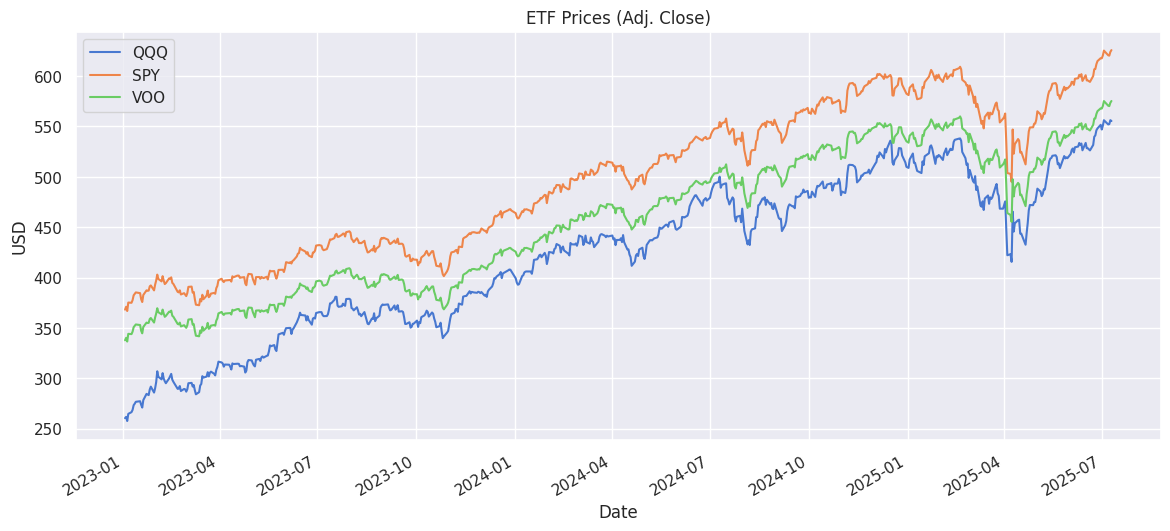

In [ ]:
etfs.plot(figsize=(14,6), title='ETF Prices (Adj. Close)')
plt.ylabel('USD')
plt.xlabel('Date')
plt.legend()
plt.show()

##Returns


The returns are given by the following expression:

$$
r_{t} = \frac{y_{t} - y_{t-1}}{y_{t-1}}
$$

Where:  
- $r_t$ is the return at time $t$  
- $y_t$ is the value (e.g., ETF price) at time $t$  
- $y_{t-1}$ is the value at the previous time step  


This measures the relative change in value from one time step to the next — a standard way to compute daily returns in finance. It helps compare performance across assets regardless of price level.

In [ ]:
returns = etfs.pct_change().dropna()
returns.head()

Ticker,QQQ,SPY,VOO
Date,,,
2023-01-04,0.004764,0.007720,0.007200
2023-01-05,-0.015655,-0.011413,-0.010922
2023-01-06,0.027601,0.022932,0.022744
2023-01-09,0.006473,-0.000567,-0.000729
2023-01-10,0.008465,0.007013,0.007128


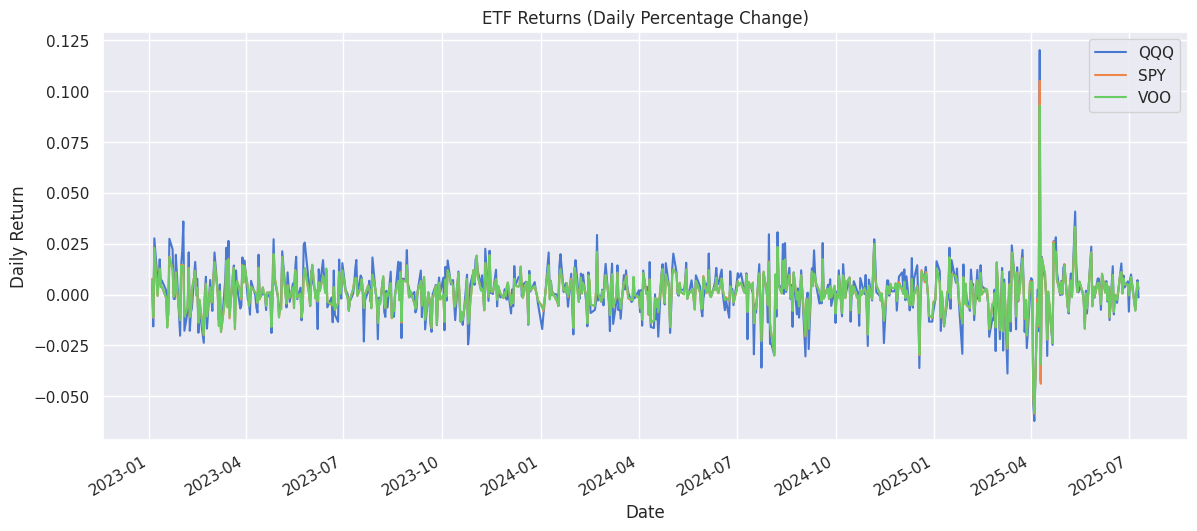

In [ ]:
returns.plot(figsize=(14,6), title='ETF Returns (Daily Percentage Change)')
plt.ylabel('Daily Return')
plt.xlabel('Date')
plt.legend()
plt.show()

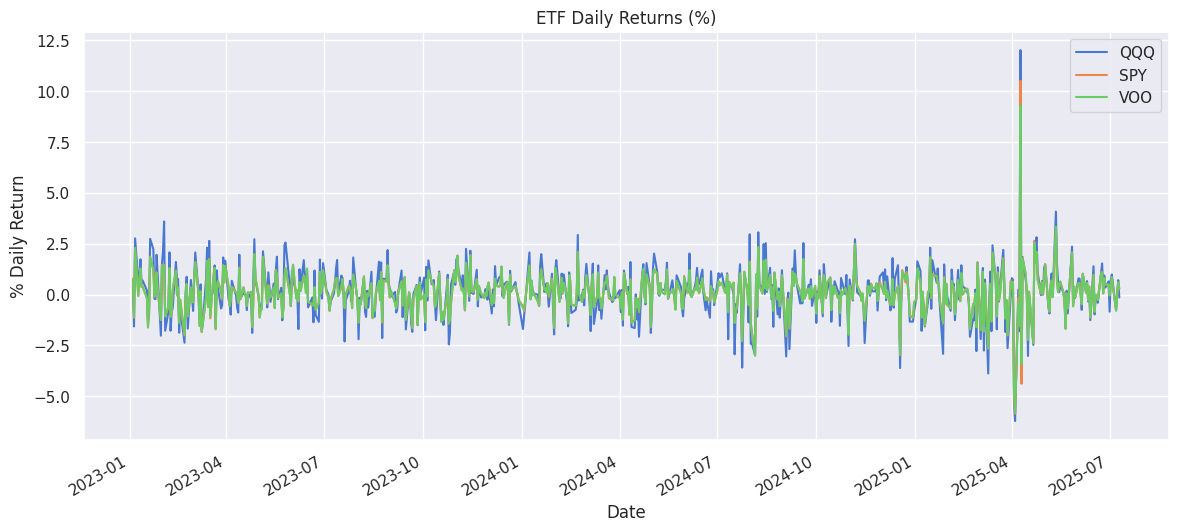

In [ ]:
(returns * 100).plot(figsize=(14,6), title='ETF Daily Returns (%)')
plt.ylabel('% Daily Return')
plt.xlabel('Date')
plt.legend()
plt.show()

## 📈 Cumulative Retuns

Given a vector of daily returns:

$$
r = [r_1, r_2, r_3, \dots, r_t]
$$

The cumulative retuns over time is given by:

$$
\text{CumulativeReturns}_t = (1 + r_1)(1 + r_2)(1 + r_3) \dots (1 + r_t)
$$

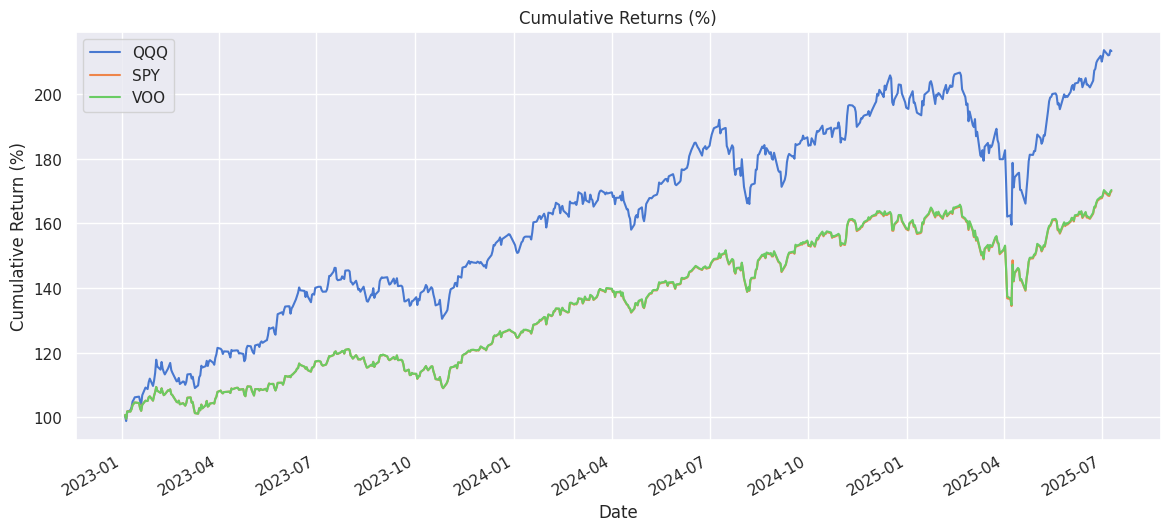

In [ ]:
((1 + returns).cumprod() * 100).plot(figsize=(14, 6), title='Cumulative Returns (%)')
plt.ylabel('Cumulative Return (%)')
plt.xlabel('Date')
plt.legend()
plt.show()

## 📊 Rolling Volatility (30-Day Window)

We estimate the **annualized rolling volatility** using the following calculation:

$$
\sigma_{\text{annual}}(t) = \sqrt{252} \times \text{std}(r_{t-30},\dots,r_t)
$$

Where:
- $\text{std}(r_{t-30},\dots,r_t)$ is the standard deviation of daily returns over the last 30 days
- $252$ is the approximate number of trading days in a year
- $\sigma_{\text{annual}}(t)$ is the annualized volatility on day $t$

This metric captures **short-term fluctuations in risk**, helping us identify periods of instability or calm in each ETF. By annualizing, we standardize volatility to make it comparable across assets and time horizons.

- A higher rolling volatility signals increased uncertainty or market turbulence.  
- Lower volatility may indicate stable price movements — useful for investors seeking predictable returns.

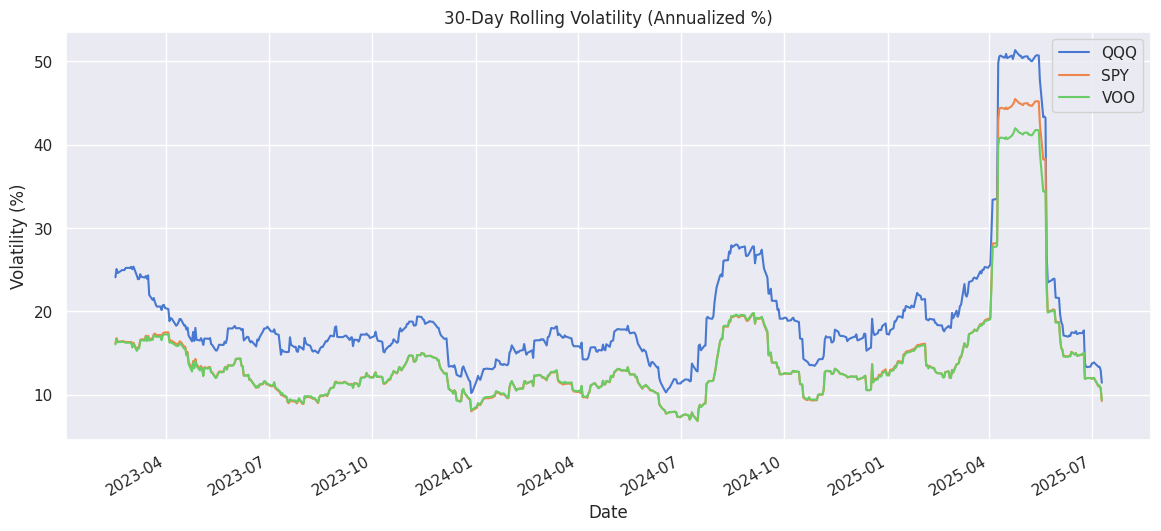

In [ ]:

rolling_vol = returns.rolling(window=30).std() * (252**0.5) * 100  # Anualizado

rolling_vol.plot(figsize=(14,6), title='30-Day Rolling Volatility (Annualized %)')
plt.ylabel('Volatility (%)')
plt.xlabel('Date')
plt.legend()
plt.show()

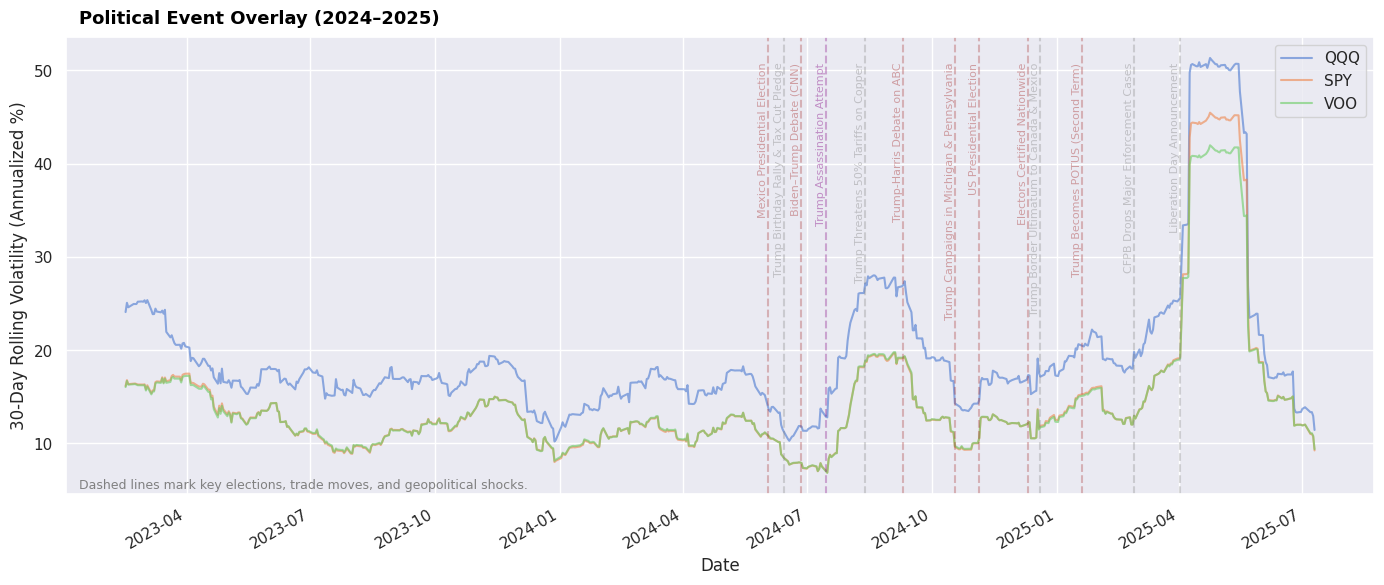

In [ ]:
# Define event categories with custom colors
event_dates = {
    'US Presidential Election': ('2024-11-05', 'Election'),
    'Trump Becomes POTUS (Second Term)': ('2025-01-20', 'Election'),
    'Mexico Presidential Election': ('2024-06-02', 'Election'),
    'Electors Certified Nationwide': ('2024-12-11', 'Election'),

    'Trump Border Ultimatum to Canada & Mexico': ('2024-12-20', 'Trade Policy'),
    'Liberation Day Announcement': ('2025-04-02', 'Trade Policy'),
    'Trump Threatens 50% Tariffs on Copper': ('2024-08-13', 'Trade Policy'),
    'CFPB Drops Major Enforcement Cases': ('2025-02-27', 'Trade Policy'),

    'Trump Assassination Attempt': ('2024-07-15', 'Geopolitical'),
    'Biden–Trump Debate (CNN)': ('2024-06-27', 'Election'),
    'Trump-Harris Debate on ABC': ('2024-09-10', 'Election'),
    'Trump Campaigns in Michigan & Pennsylvania': ('2024-10-18', 'Election'),
    'Trump Birthday Rally & Tax Cut Pledge': ('2024-06-14', 'Trade Policy')
}

# Define category colors
category_colors = {
    'Election': 'brown',
    'Trade Policy': 'gray',
    'Geopolitical': 'purple'
}

# Plot rolling volatility
ax = rolling_vol.plot(figsize=(14, 6), alpha=0.6)
plt.ylabel('30-Day Rolling Volatility (Annualized %)')
plt.xlabel('Date')
plt.legend()

# Add vertical lines and labels with category colors
for label, (date, category) in event_dates.items():
    date_obj = pd.to_datetime(date)
    ax.axvline(date_obj, color=category_colors[category], linestyle='--', alpha=0.3)
    ax.text(date_obj, ax.get_ylim()[1]*0.95, label,
            rotation=90, color=category_colors[category],
            ha='right', va='top', fontsize=8, alpha=0.4)

# Add subtitle and contextual note inside plot
ax.text(0.01, 1.03, 'Political Event Overlay (2024–2025)', transform=ax.transAxes,
        fontsize=13, color='black', fontweight='bold')

ax.text(0.01, 0.01,
        'Dashed lines mark key elections, trade moves, and geopolitical shocks.',
        transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

## 📉 Drawdown Analysis

We compute the **drawdown** as the relative loss from the most recent historical peak:

$$
\text{Drawdown}(t) = \frac{V_t - \max(V_{0 \dots t})}{\max(V_{0 \dots t})}
$$

Where:
- $V_t$ is the cumulative value of the investment at time $t$
- $\max(V_{0 \dots t})$ is the highest value observed up to time $t$

This metric tracks the percentage decline from a previous high, helping to understand **temporary losses**, **risk exposure**, and **recovery time** across assets.

📊 It reveals:
- Depth of each downturn
- Duration of recovery
- Comparative pain across ETFs

A drawdown of −25 % means the asset has lost a quarter of its value compared to its last peak — even if long-term returns remain positive.

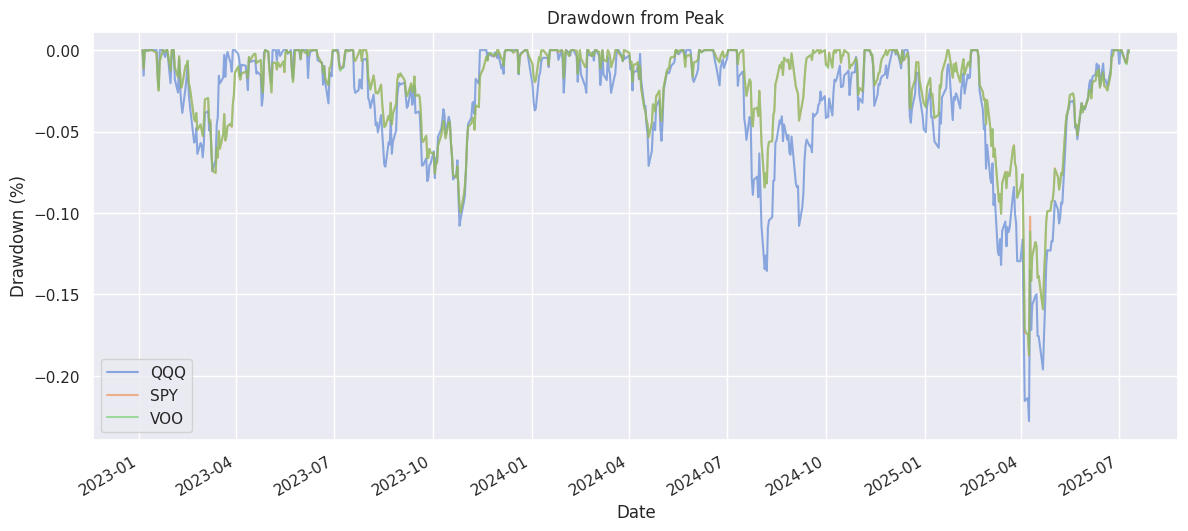

In [ ]:
cum_returns = (1 + returns).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak

drawdown.plot(figsize=(14,6), title='Drawdown from Peak', alpha=0.6)
plt.ylabel('Drawdown (%)')
plt.xlabel('Date')
plt.legend()
plt.show()

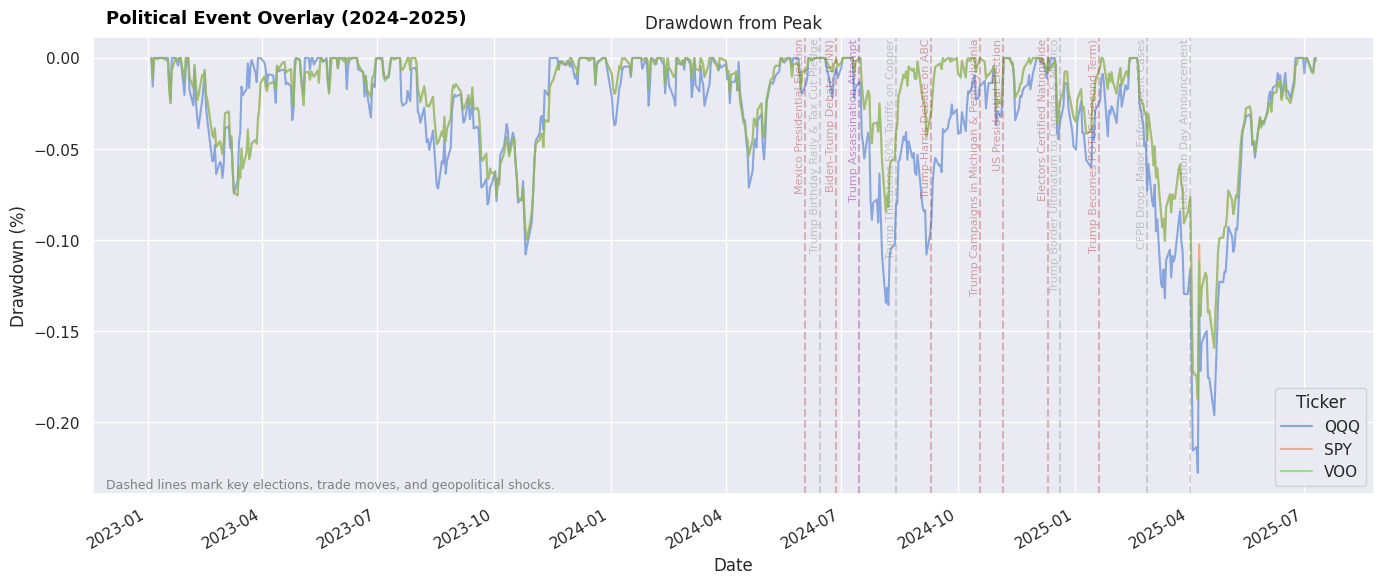

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define event categories with custom colors
event_dates = {
    'US Presidential Election': ('2024-11-05', 'Election'),
    'Trump Becomes POTUS (Second Term)': ('2025-01-20', 'Election'),
    'Mexico Presidential Election': ('2024-06-02', 'Election'),
    'Electors Certified Nationwide': ('2024-12-11', 'Election'),
    'Trump Border Ultimatum to Canada & Mexico': ('2024-12-20', 'Trade Policy'),
    'Liberation Day Announcement': ('2025-04-02', 'Trade Policy'),
    'Trump Threatens 50% Tariffs on Copper': ('2024-08-13', 'Trade Policy'),
    'CFPB Drops Major Enforcement Cases': ('2025-02-27', 'Trade Policy'),
    'Trump Assassination Attempt': ('2024-07-15', 'Geopolitical'),
    'Biden–Trump Debate (CNN)': ('2024-06-27', 'Election'),
    'Trump-Harris Debate on ABC': ('2024-09-10', 'Election'),
    'Trump Campaigns in Michigan & Pennsylvania': ('2024-10-18', 'Election'),
    'Trump Birthday Rally & Tax Cut Pledge': ('2024-06-14', 'Trade Policy')
}

# Define category colors
category_colors = {
    'Election': 'brown',
    'Trade Policy': 'gray',
    'Geopolitical': 'purple'
}

# Plot Drawdown
cum_returns = (1 + returns).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak

fig, ax = plt.subplots(figsize=(14, 6))
drawdown.plot(ax=ax, title='Drawdown from Peak', alpha=0.6)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')

# Add vertical lines and labels with category colors
for label, (date, category) in event_dates.items():
    date_obj = pd.to_datetime(date)
    ax.axvline(date_obj, color=category_colors[category], linestyle='--', alpha=0.3)
    ax.text(date_obj, ax.get_ylim()[1]*0.95, label,
            rotation=90, color=category_colors[category],
            ha='right', va='top', fontsize=8, alpha=0.4)

# Add subtitle and contextual note inside plot
ax.text(0.01, 1.03, 'Political Event Overlay (2024–2025)', transform=ax.transAxes,
        fontsize=13, color='black', fontweight='bold')

ax.text(0.01, 0.01,
        'Dashed lines mark key elections, trade moves, and geopolitical shocks.',
        transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [ ]:
recovery_summary = {}

for ticker in tickers:
    dd_series = drawdown[ticker]
    recovery_periods = []
    datess = []
    datese = []
    in_drawdown = False
    start_date = None
    #end_date = None

    for date in dd_series.index:
        if dd_series.loc[date] < 0 and not in_drawdown:
            # Start of drawdown
            in_drawdown = True
            start_date = date
        elif dd_series.loc[date] == 0 and in_drawdown:
            # Recovery achieved
            duration = (date - start_date).days
            recovery_periods.append(duration)
            datess.append(start_date)
            datese.append(date)
            in_drawdown = False
            start_date = None

    # Promedio de recuperación
    avg_duration = np.mean(recovery_periods) if recovery_periods else np.nan
    recovery_summary[ticker] = round(avg_duration, 2)

    df_name = f"{ticker}_rp"
    globals()[df_name] = pd.DataFrame({
        'start_date': datess,
        'end_date': datese,
        'recovery_days': recovery_periods
    })

# Mostrar resultados
for ticker, duration in recovery_summary.items():
    print(f"{ticker} – Average Recovery Time: {duration} days")

VOO – Average Recovery Time: 13.72 days
QQQ – Average Recovery Time: 17.79 days
SPY – Average Recovery Time: 14.06 days


In [ ]:
QQQ_rp.tail(10)

,start_date,end_date,recovery_days
32,2024-06-20,2024-07-02,12
33,2024-07-11,2024-11-06,118
34,2024-11-11,2024-12-02,21
35,2024-12-05,2024-12-06,1
36,2024-12-09,2024-12-11,2
37,2024-12-12,2024-12-13,1
38,2024-12-17,2025-02-14,59
39,2025-02-20,2025-06-24,124
40,2025-07-01,2025-07-03,2
41,2025-07-07,2025-07-09,2


/tmp/ipython-input-23-4020083150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=recovery_df, x='ticker', y='recovery_days', palette='Set2')


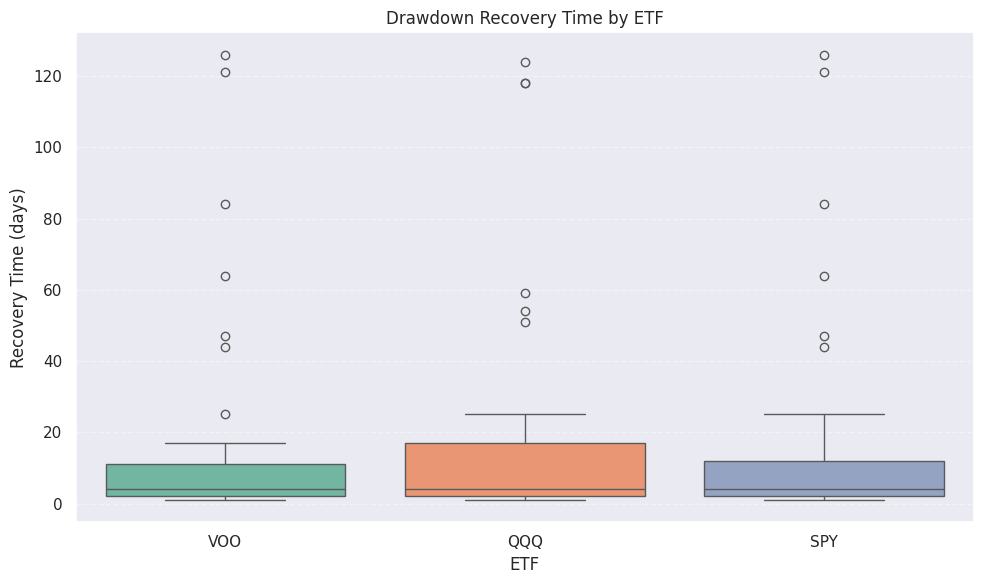

In [ ]:
recovery_df = pd.concat([
    VOO_rp.assign(ticker='VOO'),
    QQQ_rp.assign(ticker='QQQ'),
    SPY_rp.assign(ticker='SPY')
])

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=recovery_df, x='ticker', y='recovery_days', palette='Set2')
plt.title('Drawdown Recovery Time by ETF')
plt.ylabel('Recovery Time (days)')
plt.xlabel('ETF')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()